In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import cv2

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

def show(img, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

def show_pair(a, b, title1="Input", title2="Result"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    show(a, title1, axes[0])
    show(b, title2, axes[1])
    plt.tight_layout()

def show_triplet(a, b, c, t1="A", t2="B", t3="C"):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    show(a, t1, axes[0])
    show(b, t2, axes[1])
    show(c, t3, axes[2])
    plt.tight_layout()

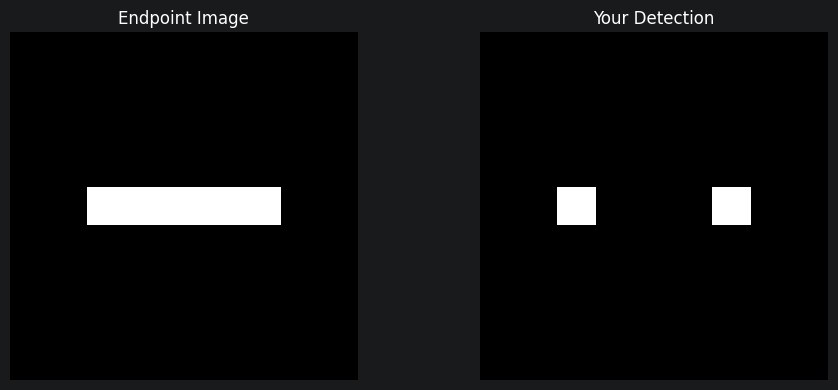

In [4]:
# Student task cell: define new B1 and B2 for endpoint detection
endpoint_img = np.zeros((9, 9), dtype=np.uint8)
endpoint_img[4, 2:7] = 1

patterns = [
    # left endpoint
    (
        np.array([[0,0,0],
                  [0,1,1],
                  [0,0,0]], dtype=bool),
        np.array([[1,1,1],
                  [1,0,0],
                  [1,1,1]], dtype=bool)
    ),

    # right endpoint
    (
        np.array([[0,0,0],
                  [1,1,0],
                  [0,0,0]], dtype=bool),
        np.array([[1,1,1],
                  [0,0,1],
                  [1,1,1]], dtype=bool)
    ),

    # top endpoint
    (
        np.array([[0,0,0],
                  [0,1,0],
                  [0,1,0]], dtype=bool),
        np.array([[1,1,1],
                  [1,0,1],
                  [1,0,1]], dtype=bool)
    ),

    # bottom endpoint
    (
        np.array([[0,1,0],
                  [0,1,0],
                  [0,0,0]], dtype=bool),
        np.array([[1,0,1],
                  [1,0,1],
                  [1,1,1]], dtype=bool)
    )
]

result_student = np.zeros_like(endpoint_img, dtype=bool)

for B1_student, B2_student in patterns:
    fg = ndimage.binary_erosion(endpoint_img, structure=B1_student)
    bg = ndimage.binary_erosion(1 - endpoint_img, structure=B2_student)
    result_student |= (fg & bg)

show_pair(endpoint_img, result_student.astype(np.uint8), "Endpoint Image", "Your Detection")
plt.show()

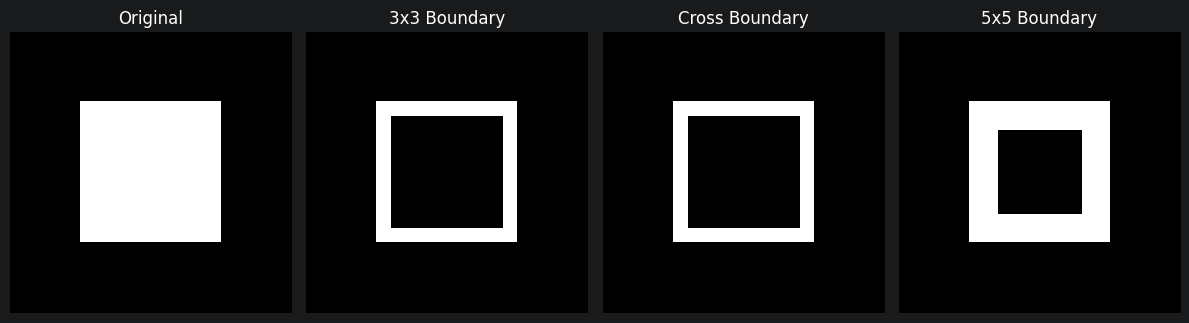

In [5]:
# Student task cell: experiment with different structuring elements
img = np.zeros((20, 20), dtype=np.uint8)
img[5:15, 5:15] = 1
se_3 = np.ones((3,3), dtype=bool)

cross = np.array([[0,1,0],
                  [1,1,1],
                  [0,1,0]], dtype=bool)

se_5 = np.ones((5,5), dtype=bool)

eroded_3 = ndimage.binary_erosion(img, structure=se_3)
eroded_cross = ndimage.binary_erosion(img, structure=cross)
eroded_5 = ndimage.binary_erosion(img, structure=se_5)

boundary_3 = img & (~eroded_3)
boundary_cross = img & (~eroded_cross)
boundary_5 = img & (~eroded_5)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(boundary_3.astype(np.uint8), cmap="gray")
plt.title("3x3 Boundary")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(boundary_cross.astype(np.uint8), cmap="gray")
plt.title("Cross Boundary")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(boundary_5.astype(np.uint8), cmap="gray")
plt.title("5x5 Boundary")
plt.axis("off")

plt.tight_layout()
plt.show()

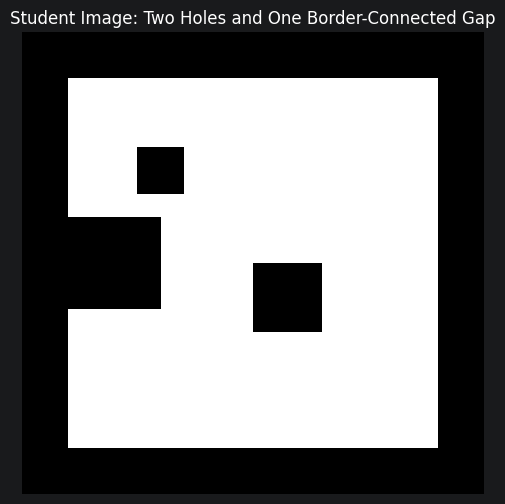

In [6]:
# Student task cell: build your own image here
student_holes = np.zeros((20, 20), dtype=np.uint8)

student_holes[2:18, 2:18] = 1

student_holes[5:7, 5:7] = 0

student_holes[10:13, 10:13] = 0

student_holes[8:12, 0:6] = 0

show(student_holes, "Student Image: Two Holes and One Border-Connected Gap")
plt.show()

Number of connected components: 3
Areas of components: [25.  1. 25.]


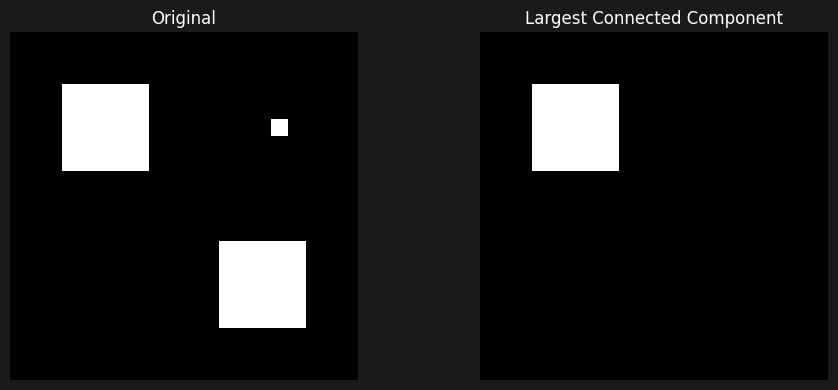

In [7]:
# Student task cell: measure areas and extract largest component
cc_img = np.zeros((20,20), dtype=np.uint8)

cc_img[3:8, 3:8] = 1

cc_img[12:17, 12:17] = 1

cc_img[5,15] = 1
labeled_student, n_student = ndimage.label(cc_img)

areas = ndimage.sum(cc_img, labeled_student, index=range(1, n_student + 1))

print("Number of connected components:", n_student)
print("Areas of components:", areas)

largest_label = np.argmax(areas) + 1
largest_component = (labeled_student == largest_label).astype(np.uint8)

show_pair(cc_img, largest_component, "Original", "Largest Connected Component")
plt.show()

Number of connected components: 5
Component 1: Area = 91 pixels
Component 2: Area = 3404 pixels
Component 3: Area = 1891 pixels
Component 4: Area = 1257 pixels
Component 5: Area = 1 pixels


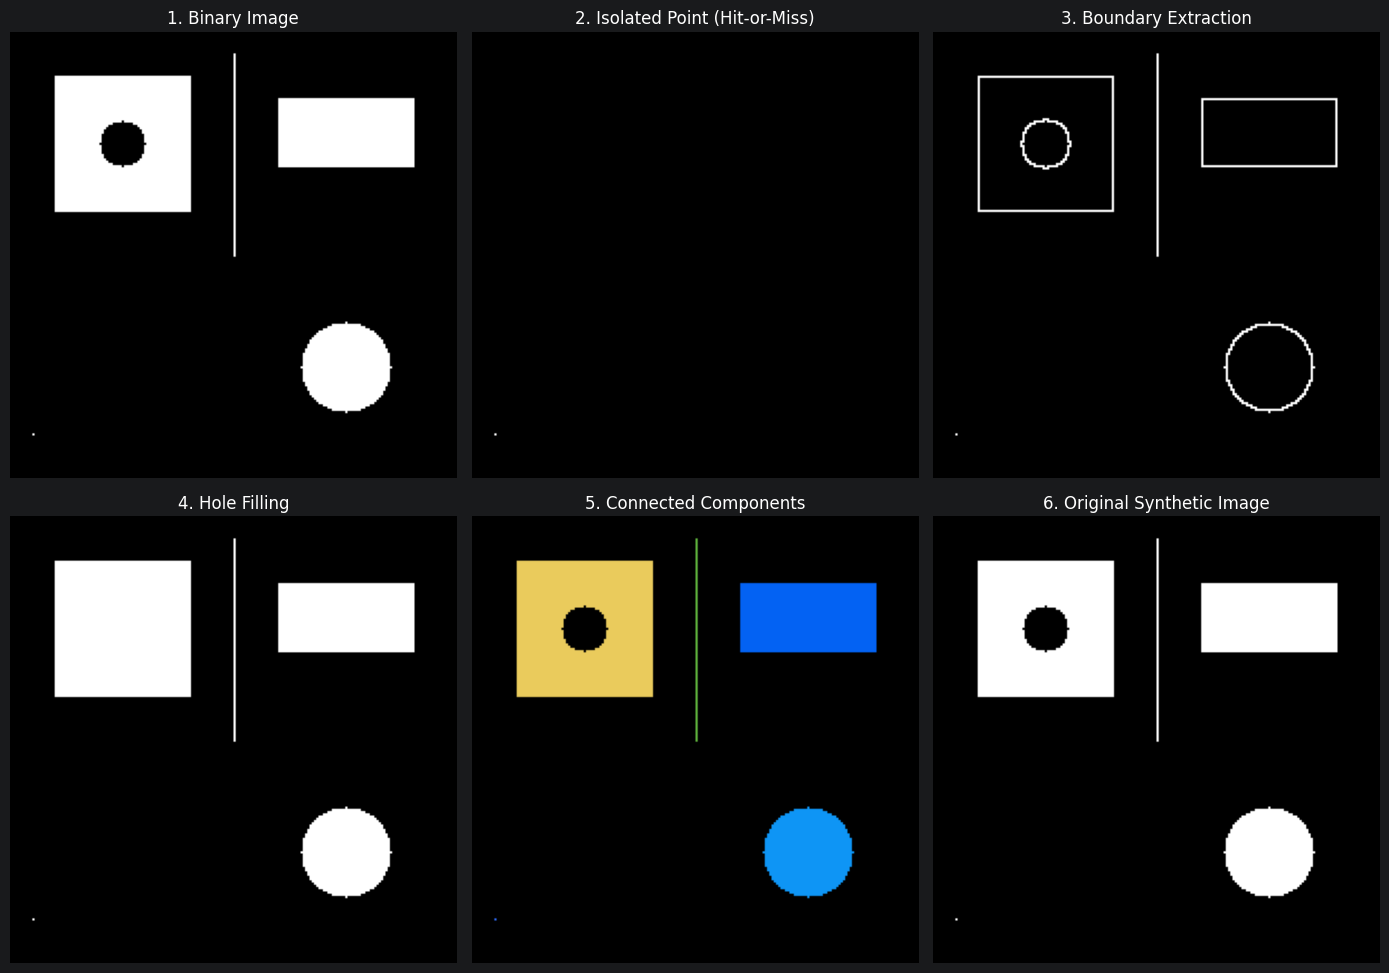

In [10]:
# Mini project for students
binary = np.zeros((200, 200), dtype=np.uint8)

cv2.rectangle(binary, (20, 20), (80, 80), 255, -1)

cv2.circle(binary, (150, 150), 20, 255, -1)

cv2.rectangle(binary, (120, 30), (180, 60), 255, -1)

cv2.circle(binary, (50, 50), 10, 0, -1)

cv2.line(binary, (100, 10), (100, 100), 255, 1)

binary[180, 10] = 255

binary01 = (binary // 255).astype(np.uint8)

kernel_hitmiss = np.array([[-1, -1, -1],
                           [-1,  1, -1],
                           [-1, -1, -1]], dtype=np.int8)

hitmiss = cv2.morphologyEx(binary01, cv2.MORPH_HITMISS, kernel_hitmiss) * 255

se = np.ones((3, 3), np.uint8)
eroded = cv2.erode(binary, se, iterations=1)
boundary = cv2.subtract(binary, eroded)

flood = binary.copy()
mask = np.zeros((binary.shape[0] + 2, binary.shape[1] + 2), np.uint8)

cv2.floodFill(flood, mask, (0, 0), 255)
holes = cv2.bitwise_not(flood)
filled = cv2.bitwise_or(binary, holes)

num_labels, labels = cv2.connectedComponents(binary)

print("Number of connected components:", num_labels - 1)

areas = []
for label in range(1, num_labels):
    area = np.sum(labels == label)
    areas.append(area)
    print(f"Component {label}: Area = {area} pixels")

component_img = np.zeros((binary.shape[0], binary.shape[1], 3), dtype=np.uint8)
np.random.seed(42)
colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
colors[0] = [0, 0, 0]

for label in range(1, num_labels):
    component_img[labels == label] = colors[label]

plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.imshow(binary, cmap='gray')
plt.title("1. Binary Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(hitmiss, cmap='gray')
plt.title("2. Isolated Point (Hit-or-Miss)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(boundary, cmap='gray')
plt.title("3. Boundary Extraction")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(filled, cmap='gray')
plt.title("4. Hole Filling")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(component_img)
plt.title("5. Connected Components")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(binary, cmap='gray')
plt.title("6. Original Synthetic Image")
plt.axis("off")

plt.tight_layout()
plt.show()